In [2]:
import os
import sys
import csv
import datetime
import glob
import joblib
import numpy as np
import datasets
import pandas as pd
from pathlib import Path
import optuna

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier as skRF
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, precision_score, f1_score
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.inspection import permutation_importance
from huggingface_hub import snapshot_download

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Geospatial related imports
from osgeo import gdalconst
from osgeo import gdal
import folium
from folium import plugins
import folium_helper

plt.style.use('fivethirtyeight')
warnings.filterwarnings('ignore')
%matplotlib inline



/Users/jigneshshah/miniforge3/envs/python_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
FIGURE_OUTPUT_DIR = "output"
RASTER_OUTPUT_DIR = "output"
MODLE_OUTPUT_DIR = "models"

#url of the dataset we will be using, this is a link to the Hugging Face repository of this tutorial
DATASET_URL = "nasa-cisto-data-science-group/modis-lake-powell-toy-dataset"

TILE = "global"
MODEL = "rf"
TEST_RATIO = 0.2
RANDOM_STATE = 42
LABEL_NAME = "water"
DATA_TYPE = np.int16
colsToDrop = []
v_names = ['sur_refl_b01_1','sur_refl_b02_1','sur_refl_b03_1',
           'sur_refl_b04_1','sur_refl_b05_1','sur_refl_b06_1',
           'sur_refl_b07_1','ndvi','ndwi1','ndwi2']




### Data Loading
We have extracted a tabular dataset from MODIS GeoTIFF files for the purpose of EDA

In [4]:
%%time
train_dataset = pd.DataFrame(datasets.load_dataset(DATASET_URL, split = "train"))
test_dataset = pd.DataFrame(datasets.load_dataset(DATASET_URL, split = "test"))

CPU times: user 121 ms, sys: 34.8 ms, total: 156 ms
Wall time: 2.96 s


In [5]:
X_train, y_train = train_dataset.drop(["water"], axis = 1), train_dataset["water"]
X_test, y_test = test_dataset.drop(["water"], axis = 1), test_dataset["water"]

In [6]:
y_test.shape

(200,)

In [7]:
X_train.columns

Index(['sur_refl_b01_1', 'sur_refl_b02_1', 'sur_refl_b03_1', 'sur_refl_b04_1',
       'sur_refl_b05_1', 'sur_refl_b06_1', 'sur_refl_b07_1', 'ndvi', 'ndwi1',
       'ndwi2'],
      dtype='object')

In [8]:
def output_interesting_idx(df, column, threshold, greaterThan = True):
    dfToReturn = df[df[column] > threshold] if \
        greaterThan else df[df[column] < threshold]
    return dfToReturn


In [9]:
output_interesting_idx(X_train, "ndvi", 10000)

,sur_refl_b01_1,sur_refl_b02_1,sur_refl_b03_1,sur_refl_b04_1,sur_refl_b05_1,sur_refl_b06_1,sur_refl_b07_1,ndvi,ndwi1,ndwi2


### Model definition and training
Set TREES_ONLY to True if you only want to tune number of estimators, else max_depth, max_samples_split, min_samples_leaf will be tuned as well. All of these parameters play an important role in the tunning of models.

In [10]:
TREES_ONLY = True

Define an objective which will iterate over mutliple hyperparameters and find the best possible optimization. 
To montior error we will metrics such as precision, the F1 score (harmonic of precision and recall), and the rate of false positives.

In [11]:
def objective(trial):
    list_trees = [75, 100, 125, 150, 175, 200, 250, 300, 400, 500]
    max_depth = [80, 90, 100, 110]
    min_samples_leaf = [1,2,3,4,5] # minimum of samples should be needed is leaf (should not go below this)
    min_samples_split = [2,4,8,10] # minimum of samples required to split further

    if TREES_ONLY:
        param = {
            'n_estimators': trial.suggest_categorical('n_estimators', list_trees), 
            'criterion':'gini', 
            'max_depth':None, 
            'min_samples_split':2, 
            'min_samples_leaf':1, 
            'min_weight_fraction_leaf':0.0, 
            'max_features':'sqrt', 
            'max_leaf_nodes':None, 
            'min_impurity_decrease':0.0, 
            'bootstrap':True, 
            'oob_score':False, 
            'n_jobs':-1, 
            'random_state':42, 
            'verbose':0, 
            'warm_start':True, 
            'class_weight':None, 
            'ccp_alpha':0.0, 
            'max_samples':None
                  
        }
    
    else:
        param = {'n_estimators': trial.suggest_categorical('n_estimators', list_trees), 
                       'max_depth':trial.suggest_categorical('max_depth', max_depth), 
                       'min_samples_split':trial.suggest_categorical('min_samples_split', min_samples_split), 
                       'min_samples_leaf':trial.suggest_categorical('min_samples_leaf', min_samples_leaf), 
                       'bootstrap': True,
                       'criterion':'gini', 
                       'min_weight_fraction_leaf':0.0, 
                       'max_features':'sqrt', 
                       'max_leaf_nodes':None, 
                       'min_impurity_decrease':0.0, 
                       'oob_score':False, 
                       'n_jobs':-1, 
                       'random_state':42, 
                       'verbose':0, 
                       'warm_start':False, 
                       'class_weight':None, 
                       'ccp_alpha':0.0, 
                       'max_samples':None
                      }
    
    rf = skRF(**param)
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    fp = cm[0][1]
    precision = precision_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    del rf, preds, cm

    return precision, f1, fp

metric = {'precision': 0, 'f1': 1, 'false_positive': 2}

### Start hyperparameter tunning trials
The metrics in order are: [precision, f1, false positives]

In [12]:
optuna.logging.set_verbosity(optuna.logging.INFO)
study = optuna.create_study(study_name="rf_tunnig", directions=['maximize', 'maximize', 'minimize'])
study.optimize(objective, n_trials=25, timeout=20*60)

[I 2025-11-17 23:05:12,053] A new study created in memory with name: rf_tunnig
[I 2025-11-17 23:05:12,139] Trial 0 finished with values: [0.9895833333333334, 0.9947643979057592, 1.0] and parameters: {'n_estimators': 75}.
[I 2025-11-17 23:05:12,376] Trial 1 finished with values: [0.979381443298969, 0.9895833333333334, 2.0] and parameters: {'n_estimators': 300}.
[I 2025-11-17 23:05:12,515] Trial 2 finished with values: [0.979381443298969, 0.9895833333333334, 2.0] and parameters: {'n_estimators': 175}.
[I 2025-11-17 23:05:12,691] Trial 3 finished with values: [0.979381443298969, 0.9895833333333334, 2.0] and parameters: {'n_estimators': 200}.
[I 2025-11-17 23:05:12,967] Trial 4 finished with values: [0.979381443298969, 0.9895833333333334, 2.0] and parameters: {'n_estimators': 300}.
[I 2025-11-17 23:05:13,165] Trial 5 finished with values: [0.979381443298969, 0.9895833333333334, 2.0] and parameters: {'n_estimators': 250}.
[I 2025-11-17 23:05:13,382] Trial 6 finished with values: [0.97938144

Get metrics from the overall hyperparameter tunning

In [13]:
METRIC_TO_USE = "f1"

From where we can select the best trial and therefore optimal parameters for our model

In [14]:
print("Number of finished trials: {}".format(len(study.trials)))
print("Using {} idx: {}".format(METRIC_TO_USE, metric[METRIC_TO_USE]))
# As we are using three matrices. There is no such single trial where all three are giving best results therefore best_trials will going to give
# some trials. This is called Pareto front

trials = study.best_trials 
if METRIC_TO_USE == "false_positive" or METRIC_TO_USE == "false_negative":
    trial_score = min([trial.values[metric[METRIC_TO_USE]]] for trial in trials)
else:
    trial_score = max([trial.values[metric[METRIC_TO_USE]]]for trial in trials)

best_trial_params = [trial.params for trial in trials if trial.values[metric[METRIC_TO_USE]] == trial_score[0]][0]
best_trial = [trial for trial in trials if trial.values[metric[METRIC_TO_USE]] == trial_score[0]][0]
print(best_trial_params)
print(best_trial)

trial_scores = [trial.values for trial in trials]
trial_params = [trial.params for trial in trials]
for score, param in zip(trial_scores, trial_params):
    print(score)
    for k, v in param.items():
        print("     {}: {}".format(k, v))

study_df = study.trials_dataframe()
study_df.to_csv("hyperopt_tuning_trial_{}_random_forest.csv".format(
    datetime.datetime.now().strftime('%Y_%m_%d_%H_%M')))


Number of finished trials: 25
Using f1 idx: 1
{'n_estimators': 75}
FrozenTrial(number=0, state=1, values=[0.9895833333333334, 0.9947643979057592, 1.0], datetime_start=datetime.datetime(2025, 11, 17, 23, 5, 12, 55178), datetime_complete=datetime.datetime(2025, 11, 17, 23, 5, 12, 139364), params={'n_estimators': 75}, user_attrs={}, system_attrs={'NSGAIISampler:generation': 0}, intermediate_values={}, distributions={'n_estimators': CategoricalDistribution(choices=(75, 100, 125, 150, 175, 200, 250, 300, 400, 500))}, trial_id=0, value=None)
[0.9895833333333334, 0.9947643979057592, 1.0]
     n_estimators: 75
[0.9895833333333334, 0.9947643979057592, 1.0]
     n_estimators: 125
[0.9895833333333334, 0.9947643979057592, 1.0]
     n_estimators: 125
[0.9895833333333334, 0.9947643979057592, 1.0]
     n_estimators: 75
[0.9895833333333334, 0.9947643979057592, 1.0]
     n_estimators: 125


In [15]:
trials = study.best_trials
for trial in trials:
    print(trial)
    print(trial.values[metric[METRIC_TO_USE]])

FrozenTrial(number=0, state=1, values=[0.9895833333333334, 0.9947643979057592, 1.0], datetime_start=datetime.datetime(2025, 11, 17, 23, 5, 12, 55178), datetime_complete=datetime.datetime(2025, 11, 17, 23, 5, 12, 139364), params={'n_estimators': 75}, user_attrs={}, system_attrs={'NSGAIISampler:generation': 0}, intermediate_values={}, distributions={'n_estimators': CategoricalDistribution(choices=(75, 100, 125, 150, 175, 200, 250, 300, 400, 500))}, trial_id=0, value=None)
0.9947643979057592
FrozenTrial(number=14, state=1, values=[0.9895833333333334, 0.9947643979057592, 1.0], datetime_start=datetime.datetime(2025, 11, 17, 23, 5, 14, 814651), datetime_complete=datetime.datetime(2025, 11, 17, 23, 5, 14, 922539), params={'n_estimators': 125}, user_attrs={}, system_attrs={'NSGAIISampler:generation': 0}, intermediate_values={}, distributions={'n_estimators': CategoricalDistribution(choices=(75, 100, 125, 150, 175, 200, 250, 300, 400, 500))}, trial_id=14, value=None)
0.9947643979057592
FrozenTr

<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

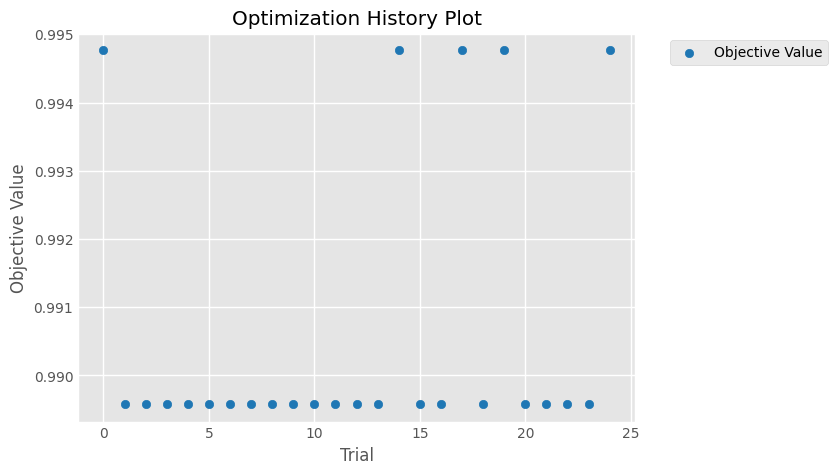

In [16]:
optuna.visualization.matplotlib.plot_optimization_history(study, target=lambda t: t.values[metric[METRIC_TO_USE]])

Visualize the loss functions compares to number of estimators during tuning

In [17]:
udf = study_df.drop_duplicates(["params_n_estimators"]).sort_values(by = "params_n_estimators")
udf_by_score = udf[udf.values_0 == udf.values_0.max()]
udf

,number,values_0,values_1,values_2,datetime_start,datetime_complete,duration,params_n_estimators,system_attrs_NSGAIISampler:generation,state
0,0,0.989583,0.994764,1.0,2025-11-17 23:05:12.055178,2025-11-17 23:05:12.139364,0 days 00:00:00.084186,75,0,COMPLETE
9,9,0.979381,0.989583,2.0,2025-11-17 23:05:14.049091,2025-11-17 23:05:14.145702,0 days 00:00:00.096611,100,0,COMPLETE
14,14,0.989583,0.994764,1.0,2025-11-17 23:05:14.814651,2025-11-17 23:05:14.922539,0 days 00:00:00.107888,125,0,COMPLETE
11,11,0.979381,0.989583,2.0,2025-11-17 23:05:14.240721,2025-11-17 23:05:14.364545,0 days 00:00:00.123824,150,0,COMPLETE
2,2,0.979381,0.989583,2.0,2025-11-17 23:05:12.376762,2025-11-17 23:05:12.515757,0 days 00:00:00.138995,175,0,COMPLETE
3,3,0.979381,0.989583,2.0,2025-11-17 23:05:12.516501,2025-11-17 23:05:12.691535,0 days 00:00:00.175034,200,0,COMPLETE
5,5,0.979381,0.989583,2.0,2025-11-17 23:05:12.968613,2025-11-17 23:05:13.165608,0 days 00:00:00.196995,250,0,COMPLETE
1,1,0.979381,0.989583,2.0,2025-11-17 23:05:12.139928,2025-11-17 23:05:12.376146,0 days 00:00:00.236218,300,0,COMPLETE
12,12,0.979381,0.989583,2.0,2025-11-17 23:05:14.365251,2025-11-17 23:05:14.674809,0 days 00:00:00.309558,400,0,COMPLETE
7,7,0.979381,0.989583,2.0,2025-11-17 23:05:13.383370,2025-11-17 23:05:13.804140,0 days 00:00:00.420770,500,0,COMPLETE


In [18]:
study_df

,number,values_0,values_1,values_2,datetime_start,datetime_complete,duration,params_n_estimators,system_attrs_NSGAIISampler:generation,state
0,0,0.989583,0.994764,1.0,2025-11-17 23:05:12.055178,2025-11-17 23:05:12.139364,0 days 00:00:00.084186,75,0,COMPLETE
1,1,0.979381,0.989583,2.0,2025-11-17 23:05:12.139928,2025-11-17 23:05:12.376146,0 days 00:00:00.236218,300,0,COMPLETE
2,2,0.979381,0.989583,2.0,2025-11-17 23:05:12.376762,2025-11-17 23:05:12.515757,0 days 00:00:00.138995,175,0,COMPLETE
3,3,0.979381,0.989583,2.0,2025-11-17 23:05:12.516501,2025-11-17 23:05:12.691535,0 days 00:00:00.175034,200,0,COMPLETE
4,4,0.979381,0.989583,2.0,2025-11-17 23:05:12.692048,2025-11-17 23:05:12.967939,0 days 00:00:00.275891,300,0,COMPLETE
5,5,0.979381,0.989583,2.0,2025-11-17 23:05:12.968613,2025-11-17 23:05:13.165608,0 days 00:00:00.196995,250,0,COMPLETE
6,6,0.979381,0.989583,2.0,2025-11-17 23:05:13.166204,2025-11-17 23:05:13.382786,0 days 00:00:00.216582,250,0,COMPLETE
7,7,0.979381,0.989583,2.0,2025-11-17 23:05:13.383370,2025-11-17 23:05:13.804140,0 days 00:00:00.420770,500,0,COMPLETE
8,8,0.979381,0.989583,2.0,2025-11-17 23:05:13.804813,2025-11-17 23:05:14.048284,0 days 00:00:00.243471,250,0,COMPLETE
9,9,0.979381,0.989583,2.0,2025-11-17 23:05:14.049091,2025-11-17 23:05:14.145702,0 days 00:00:00.096611,100,0,COMPLETE


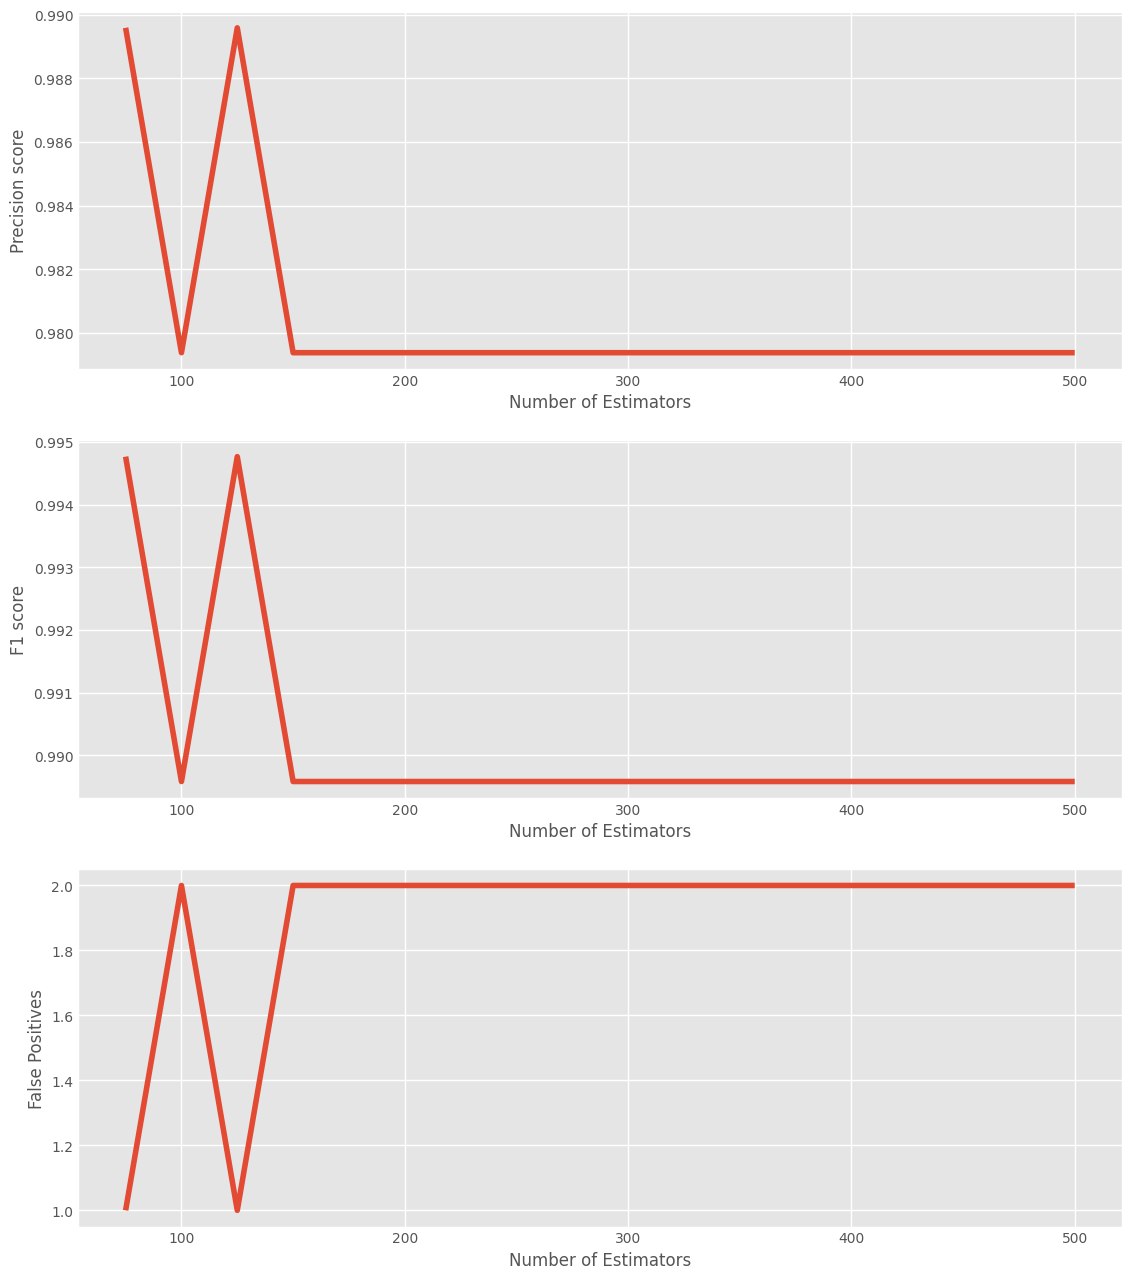

In [19]:
if TREES_ONLY:
    udf = study_df.drop_duplicates(['params_n_estimators']).sort_values(by = 'params_n_estimators')
    udf_by_score = udf[udf.values_0 == udf.values_0.max()]
    fig, ax = plt.subplots(3, figsize = (12, 15))
    ax[0].plot(udf['params_n_estimators'], udf['values_0'], label = "Precision per n estimators")
    ax[0].set_xlabel('Number of Estimators')
    ax[0].set_ylabel('Precision score')
    ax[1].plot(udf['params_n_estimators'], udf['values_1'], label = "F1 score per n estimtors")
    ax[1].set_xlabel('Number of Estimators')
    ax[1].set_ylabel('F1 score')
    ax[2].plot(udf['params_n_estimators'], udf['values_2'], label = "False positives per n estimators")
    ax[2].set_xlabel('Number of Estimators')
    ax[2].set_ylabel('False Positives')
    




Training the model with the best hyperparameters

In [20]:
hyperparameters = best_trial_params
hyperparameters['n_jobs'] = -1
hyperparameters['warm_start'] = True
print('Using these params:')
print(hyperparameters)
classifier=skRF(**hyperparameters)

Using these params:
{'n_estimators': 75, 'n_jobs': -1, 'warm_start': True}


Creating a kFold training strategy to use the new hyperparameters

In [21]:
kf = KFold(n_splits=5)
kf.get_n_splits(X_train)

5

Start training the model using the k-Fold strategy to use the best mode, this time after hyperparameter tunning

In [22]:
bestModel = None
bestModelScore = 0
scores = []
for trainIdx, testIdx in kf.split(X_train):
    print(f"Train {trainIdx}, Test {testIdx}")
    X_train_valid, X_test_valid = X_train.iloc[trainIdx], X_train.iloc[testIdx]
    y_train_valid, y_test_valid = y_train.iloc[trainIdx], y_train.iloc[testIdx]
    print("Fitting Model")
    classifier.fit(X_train_valid, y_train_valid)
    print("Getting score")
    score = classifier.score(X_test_valid, y_test_valid)
    if score>=bestModelScore:
        bestModelScore = score
        print("Training accuracy score : {}".format(score))
        bestModel = classifier

    print("Prediciting for test set")
    test_predictions = classifier.predict(X_test_valid)
    print(classification_report(y_test_valid, test_predictions))
    print(f"Score: {score}")
    scores.append(score)
    del test_predictions, score


Train [160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177
 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195
 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213
 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231
 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249
 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267
 268 269 270 271 272 273 274 275 276 277 278 279 280 281 282 283 284 285
 286 287 288 289 290 291 292 293 294 295 296 297 298 299 300 301 302 303
 304 305 306 307 308 309 310 311 312 313 314 315 316 317 318 319 320 321
 322 323 324 325 326 327 328 329 330 331 332 333 334 335 336 337 338 339
 340 341 342 343 344 345 346 347 348 349 350 351 352 353 354 355 356 357
 358 359 360 361 362 363 364 365 366 367 368 369 370 371 372 373 374 375
 376 377 378 379 380 381 382 383 384 385 386 387 388 389 390 391 392 393
 394 395 396 397 398 399 400 401 402 403 404 

Then we can take the average score from all iterations, and the score of the best model:

In [24]:
scoreAvg = np.asarray(scores).mean()
print("Average accuracy score : {}".format(scoreAvg))
print("Best accuracy score : {}".format(bestModelScore))


Average accuracy score : 0.99375
Best accuracy score : 1.0


### Model testing and training/testing data validation
Once we have trained our model we can proceed to use the best model and perform testing and validation using our dataset

#### 6.1 Get model metrics
We can calculate accuracy metrics from our model using the test dataset, but we can also output predicition probablites to understand the drivers
behind the model perfomance

In [25]:
classifier = bestModel


In [26]:
score = classifier.score(X_test, y_test)
score = round(score, 3)
score

0.985

Note how easy it is to perform predicitions once we have datasets in dataframe format

In [27]:
train_predicitions = classifier.predict(X_train)
test_predictions = classifier.predict(X_test)
prediction_proba = classifier.predict_proba(X_test) 

In [28]:
test_predictions = test_predictions.astype(np.int16)
y_test_int = y_test.astype(np.int16)

We can then produce our confusion matrix and get additional information the score of the model

In [29]:
print("Train Performance")
print('-------------------------------------------------------')
print(classification_report(y_train, train_predicitions))
print("Test Performance")
print('-------------------------------------------------------')
print(classification_report(y_test, test_predictions))
cm = confusion_matrix(y_test_int, test_predictions)
recall = (cm[0][0] / (cm[0][0] + cm[0][1]))
print("Test Recall")
print('-------------------------------------------------------')
print(recall)
print('Confusion Matrix')
print('-------------------------------------------------------')
print(cm)

Train Performance
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       395
           1       0.99      1.00      0.99       405

    accuracy                           0.99       800
   macro avg       0.99      0.99      0.99       800
weighted avg       0.99      0.99      0.99       800

Test Performance
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       105
           1       0.98      0.99      0.98        95

    accuracy                           0.98       200
   macro avg       0.98      0.99      0.98       200
weighted avg       0.99      0.98      0.99       200

Test Recall
-------------------------------------------------------
0.9809523809523809
Confusion Matrix
-------------------------------------------------------
[[103   2]
 [  1  94]]


In [30]:
%%time
permutation_importance_results = permutation_importance(classifier,
                                                        X=X_test,
                                                        y=y_test,
                                                        n_repeats=10,
                                                        random_state=42)

CPU times: user 467 ms, sys: 465 ms, total: 932 ms
Wall time: 1.51 s


Text(0.5, 0, 'Permutation Importance')

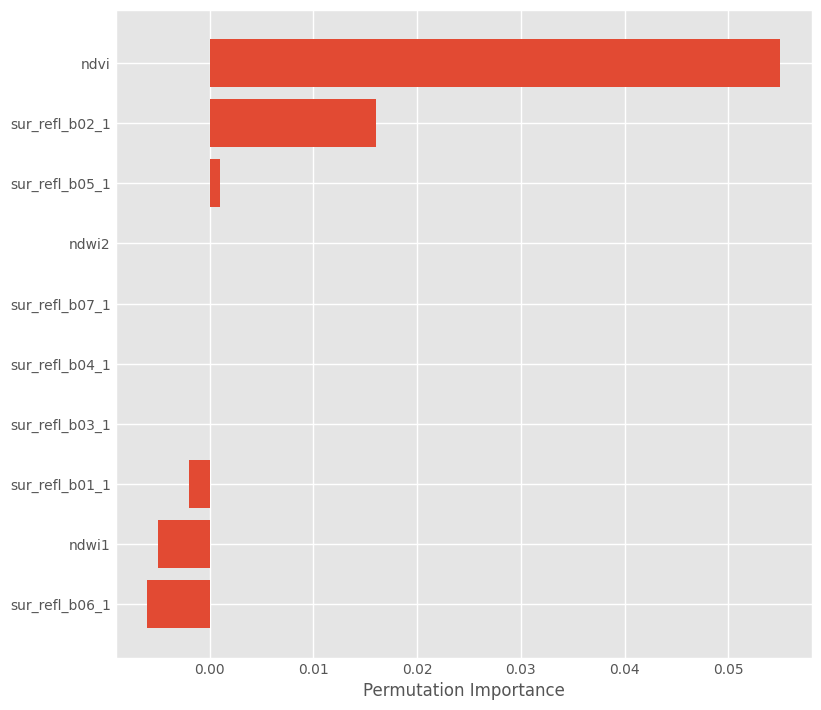

In [31]:
sorted_idx = permutation_importance_results.importances_mean.argsort()
plt.figure(figsize=(8, 8))
plt.barh(X_test.columns[sorted_idx], permutation_importance_results.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")

### Save the model

In [32]:
model_save_path = './water_classifier_rf_cpu.sav'
print('Saving model to: {}'.format(model_save_path))
print(classifier)
joblib.dump(classifier, model_save_path, compress=3)

Saving model to: ./water_classifier_rf_cpu.sav
RandomForestClassifier(n_estimators=75, n_jobs=-1, warm_start=True)


['./water_classifier_rf_cpu.sav']

### Raster Inference

In [33]:
powel_dataset = snapshot_download(repo_id=DATASET_URL, allow_patterns="*.tif", repo_type="dataset")

Fetching 11 files: 100%|██████████| 11/11 [00:00<00:00, 155344.59it/s]


In [34]:
powel_dataset

'/Users/jigneshshah/.cache/huggingface/hub/datasets--nasa-cisto-data-science-group--modis-lake-powell-toy-dataset/snapshots/e22fb0ce2c73d603ff182183fbfc1476d0032d1d'

In [35]:
fileList = sorted([file for file in glob.glob(os.path.join(powel_dataset, 'IL.*.Powell.*.tif')) if "sur_refl" in file])

In [37]:
def readRastersToArray(fileList):
    rasterProjection = None
    newshp = (1300*1300, 10)
    img = np.empty(newshp, dtype=np.int16)
    for i, fileName in enumerate(fileList):
        ds = gdal.Open(fileName)
        img[:, i] = ds.GetRasterBand(1).ReadAsArray().astype(np.int16).ravel()
        if i == 0:
            rasterProjection = ds.GetProjection()
        ds = None
    img[:, len(fileList)] = ((img[:, 1] - img[:, 0]) / (img[:, 1] + img[:, 0])) * 10000
    img[:, len(fileList)+1] = ((img[:, 1] - img[:, 5]) / (img[:, 1] + img[:, 5])) * 10000
    img[:, len(fileList)+2] = ((img[:, 1] - img[:, 6]) / (img[:, 1] + img[:, 6])) * 10000

    return img, rasterProjection





In [38]:
%%time
im, rasterProjection = readRastersToArray(fileList)
print("Raster as ndarray")
print(im)
print("{} MB in size".format((im.size * im.itemsize) / 1000000))

Raster as ndarray
[[ 1547  2461   857 ...  2280  -518   510]
 [ 1474  2377   857 ...  2344  -691   337]
 [ 1474  2377   846 ...  2344  -472   623]
 ...
 [ 2358  2979  1028 ...  1163 -1727 -1292]
 [ 2425  3069  1117 ...  1172 -1721 -1216]
 [ 2402  3038  1117 ...  1169 -1770 -1266]]
33.8 MB in size
CPU times: user 82.5 ms, sys: 43.1 ms, total: 126 ms
Wall time: 273 ms


In [39]:
#Convert raster to dataframe
raster_dataframe = pd.DataFrame(im, columns=v_names, dtype=np.float32)
raster_dataframe

,sur_refl_b01_1,sur_refl_b02_1,sur_refl_b03_1,sur_refl_b04_1,sur_refl_b05_1,sur_refl_b06_1,sur_refl_b07_1,ndvi,ndwi1,ndwi2
0,1547.0,2461.0,857.0,1256.0,2684.0,2730.0,2222.0,2280.0,-518.0,510.0
1,1474.0,2377.0,857.0,1256.0,2684.0,2730.0,2222.0,2344.0,-691.0,337.0
2,1474.0,2377.0,846.0,1230.0,2630.0,2613.0,2098.0,2344.0,-472.0,623.0
3,1494.0,2461.0,846.0,1230.0,2630.0,2613.0,2098.0,2445.0,-299.0,796.0
4,1494.0,2461.0,846.0,1230.0,2630.0,2613.0,2098.0,2445.0,-299.0,796.0
...,...,...,...,...,...,...,...,...,...,...
1689995,2211.0,2826.0,1080.0,1796.0,3650.0,4266.0,3862.0,1220.0,-2030.0,-1549.0
1689996,2209.0,2801.0,1028.0,1791.0,3633.0,4223.0,3863.0,1181.0,-2024.0,-1593.0
1689997,2358.0,2979.0,1028.0,1791.0,3633.0,4223.0,3863.0,1163.0,-1727.0,-1292.0
1689998,2425.0,3069.0,1117.0,1876.0,3747.0,4345.0,3919.0,1172.0,-1721.0,-1216.0


In [40]:
def predictraster(dataframe, colsToDrop=None):
    """
    Function given a raster in the form of a 
    GPU/CPU-bound data frame then perform
    predictions given the loaded model

    Return the prediction matrix, the prediction probablities
    for each and the dataframe converted to host.



    """
    df = dataframe.drop(columns = colsToDrop) if colsToDrop else dataframe
    print("Making predictions from raster")
    predictions = classifier.predict(df).astype(np.int16)
    predictionsProbs = classifier.predict_proba(df).astype(np.float32)
    return predictions, predictionsProbs



Once we have our features in the correct format, we can proceed to perform the inference using the model we previously saved

In [41]:
%%time
predictRaster, predictedProbaRaster = predictraster(raster_dataframe)


Making predictions from raster
CPU times: user 1.77 s, sys: 923 ms, total: 2.69 s
Wall time: 488 ms


In [42]:
predictRaster

array([0, 0, 0, ..., 0, 0, 0], shape=(1690000,), dtype=int16)

### Reshape the unravelled matrix back to the 4800*4800 raster shape
Here we reshape the raster back into the original shape for further visualization

In [43]:
raster_shape = (1300, 1300)
predictedRasterNdArray = np.asarray(predictRaster)
predictedRasterMatrix = predictedRasterNdArray.reshape(raster_shape)
predictedRasterMatrix.shape

(1300, 1300)

### Postprocessing


In [45]:
qa = [file for file in glob.glob(os.path.join(powel_dataset, 'IL.*.Powell.*.tif')) if 'qa' in file][0]
ds = gdal.Open(qa)
qaMask = ds.GetRasterBand(1).ReadAsArray()
qaMask

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1300, 1300), dtype=int16)

### Mask out results if QA Mask says pixel is bad

In [46]:
raster_qad = np.where(qaMask == 0, predictedRasterMatrix, 255)

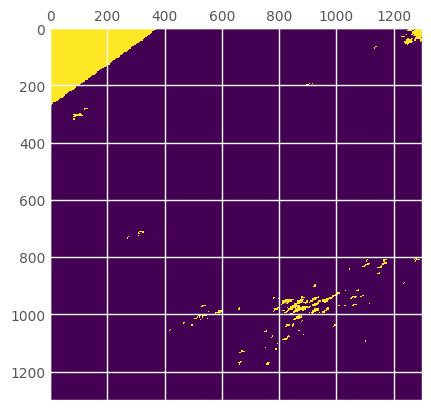

In [47]:
plt.matshow(raster_qad)
plt.show()

### Output predicted raster to GeoTiff

In [48]:
geoTransform = (-9961223.407, 231.65635, 0.0, 4285642.633667, 0.0, -231.65635)

predictedPath = 'PowellPredictedWaterMask.tif'

driver = gdal.GetDriverByName('GTiff')
outDs = driver.Create(predictedPath, 1300, 1300, 1, gdal.GDT_Int16, options=['COMPRESS=LZW'])
outDs.SetGeoTransform(geoTransform)
outDs.SetProjection(rasterProjection)
outBand = outDs.GetRasterBand(1)
outBand.WriteArray(raster_qad)
outBand.SetNoDataValue(255)
outDs.FlushCache()
outDs = None
outBand = None
driver = None

In [49]:
mask_3857 = folium_helper.reproject_to_3857(predictedPath)
mask_d = folium_helper.get_bounds(mask_3857)
mask_b1 = folium_helper.open_and_get_band(mask_3857, 1)
folium_helper.cleanup(mask_3857)
mask_b1 = np.where(mask_b1 == 255, 0, mask_b1)
zeros = np.zeros_like(mask_b1)
mask_rgb = np.dstack((mask_b1, zeros, zeros))

Transform: | 491.82, 0.00,-12749861.52|
| 0.00,-491.82, 4656230.30|
| 0.00, 0.00, 1.00|
Width: 1670 Height: 770



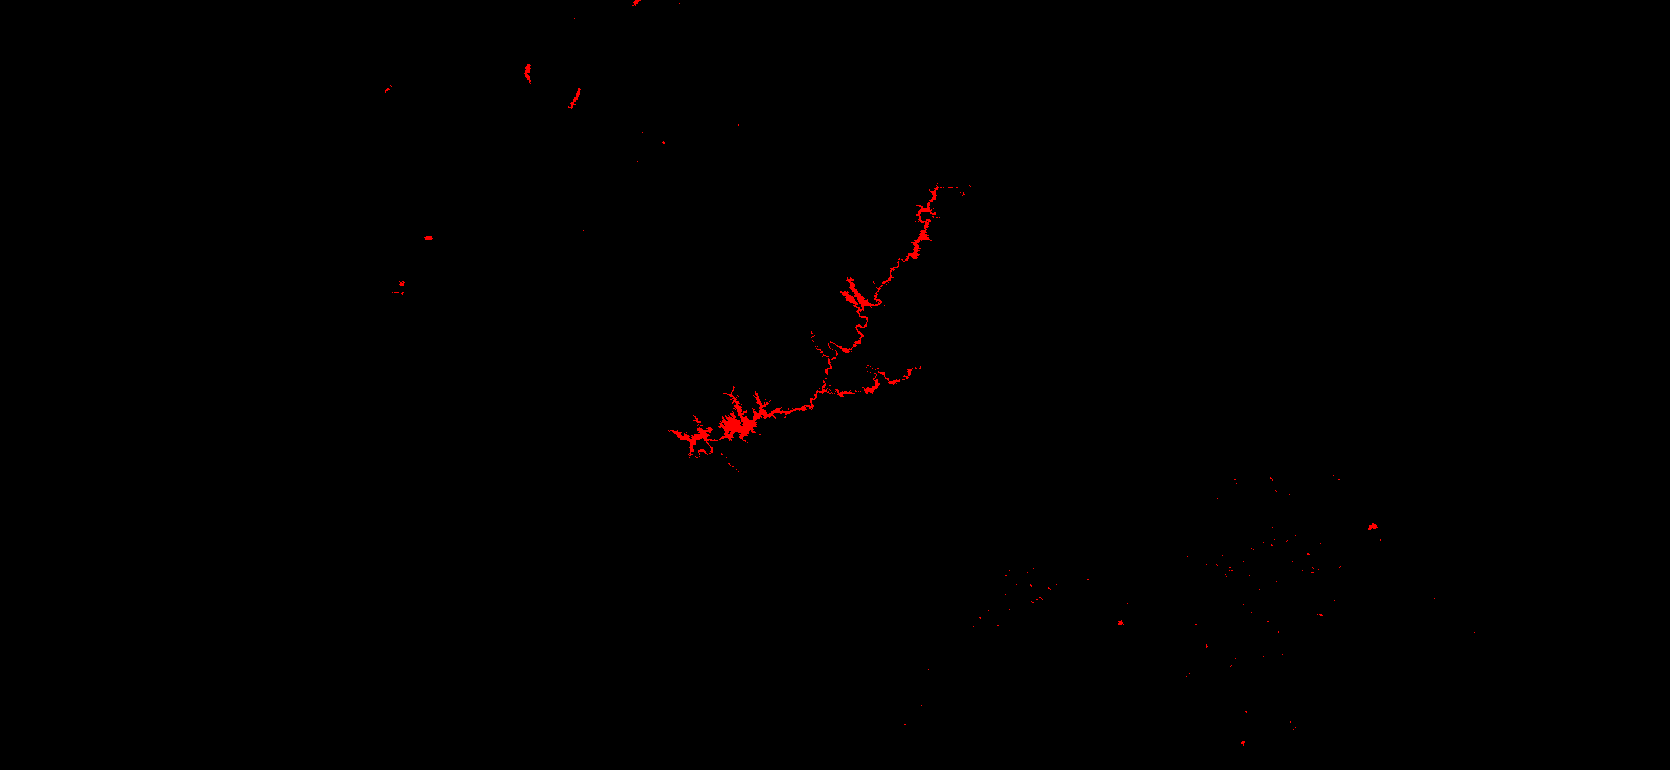

In [50]:
m = folium.Map(location=[mask_d['center'][1], mask_d['center'][0]],
                   tiles='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}', zoom_start = 6, attr='Google')
m.add_child(folium_helper.get_overlay(mask_rgb, mask_d, 'Water classification RF predicted mask', opacity=0.6))
m.add_child(plugins.MousePosition())
m.add_child(folium.LayerControl())